# Notebook 11 — Learned Gap Model

**prime-numbers-lab**

This notebook tests whether the reconstruction limit observed in Notebook 10 comes from the gap model itself.

Notebook 10 showed that adaptive weighting does not materially improve reconstruction once density and local-gap constraints are already saturated. Notebook 11 replaces the baseline

`expected gap ≈ log(x)`

with learned corrections:

1. log baseline
2. affine log baseline
3. sinusoidal log-space correction
4. local rolling correction
5. combined learned correction

Goal:

> decide whether prime-gap reconstruction improves when the expected-gap model is learned rather than fixed.

In [1]:
# --- Standard imports ---
import math
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.grid": True,
    "font.size": 12,
})

NOTEBOOK_ID = "11"
SLUG = "learned_gap_model"
RUN_DIR = Path(f"{NOTEBOOK_ID}_{SLUG}")
DATA_DIR = RUN_DIR / "data"
DOCS_DIR = RUN_DIR / "docs"
FIG_DIR = RUN_DIR / "figures"
TEX_DIR = RUN_DIR / "tex"

for d in [RUN_DIR, DATA_DIR, DOCS_DIR, FIG_DIR, TEX_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(9423)
print(f"Run directory: {RUN_DIR}")


Run directory: 11_learned_gap_model


## 1. Generate primes and gap data

We use a sieve of Eratosthenes so the notebook is self-contained and reproducible in Colab.

In [2]:
def sieve_primes(n: int) -> np.ndarray:
    """Return all primes <= n."""
    if n < 2:
        return np.array([], dtype=np.int64)
    is_prime = np.ones(n + 1, dtype=bool)
    is_prime[:2] = False
    limit = int(n**0.5) + 1
    for p in range(2, limit):
        if is_prime[p]:
            is_prime[p*p:n+1:p] = False
    return np.flatnonzero(is_prime).astype(np.int64)

MAX_N = 1_000_000
primes = sieve_primes(MAX_N)
xs = primes[:-1].astype(float)
gaps = np.diff(primes).astype(float)
logx = np.log(xs)

# Avoid tiny-x edge effects for model fitting.
mask = xs >= 100
x = xs[mask]
y = gaps[mask]
lx = np.log(x)

print(f"primes <= {MAX_N:,}: {len(primes):,}")
print(f"gap observations after x>=100: {len(y):,}")
print(f"mean gap: {y.mean():.4f}, mean log(x): {lx.mean():.4f}")


primes <= 1,000,000: 78,498
gap observations after x>=100: 78,472
mean gap: 12.7419, mean log(x): 12.7228


## 2. Baseline and learned gap models

The baseline is `log(x)`.  Learned models try to preserve interpretability:

- **affine log**: `a log(x) + b`
- **sinusoidal correction**: `a log(x) + b + c sin(k log x) + d cos(k log x)`
- **local rolling correction**: smoothed residual correction over x-windows
- **combined correction**: sinusoidal model plus local residual smoothing

In [3]:
def fit_linear_design(X: np.ndarray, y: np.ndarray):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    pred = X @ beta
    return beta, pred

def metrics(y_true, y_pred):
    residual = y_true - y_pred
    mae = float(np.mean(np.abs(residual)))
    rmse = float(np.sqrt(np.mean(residual**2)))
    bias = float(np.mean(residual))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if np.std(y_pred) > 0 else float("nan")
    return {"MAE": mae, "RMSE": rmse, "bias": bias, "corr": corr}

# Model 0: fixed baseline.
pred_log = lx.copy()

# Model 1: affine log.
X_affine = np.column_stack([lx, np.ones_like(lx)])
beta_affine, pred_affine = fit_linear_design(X_affine, y)

# Model 2: choose a sinusoidal log-frequency by validation-like grid on full diagnostic sample.
freq_grid = np.linspace(0.5, 12.0, 80)
best = None
for k in freq_grid:
    X = np.column_stack([lx, np.ones_like(lx), np.sin(k * lx), np.cos(k * lx)])
    beta, pred = fit_linear_design(X, y)
    rmse = metrics(y, pred)["RMSE"]
    if best is None or rmse < best[0]:
        best = (rmse, k, beta, pred)

_, best_k, beta_sin, pred_sin = best
print(f"affine beta: slope={beta_affine[0]:.6f}, intercept={beta_affine[1]:.6f}")
print(f"best sinusoidal log-frequency k={best_k:.4f}")
print(f"sin beta={beta_sin}")


affine beta: slope=0.994148, intercept=0.093512
best sinusoidal log-frequency k=12.0000
sin beta=[ 0.99472053  0.08697049  0.00382245 -0.021019  ]


## 3. Local rolling correction

A purely global model still misses local structure.  We therefore smooth residuals over neighboring observations and add that correction back to the baseline.

This is not a proof of prediction power.  It is a diagnostic: it asks whether the previous limit was caused by using an underfit expected-gap model.

In [4]:
def rolling_mean_same(values: np.ndarray, window: int) -> np.ndarray:
    """Centered rolling mean with edge padding, same length as input."""
    if window <= 1:
        return values.copy()
    if window % 2 == 0:
        window += 1
    pad = window // 2
    padded = np.pad(values, (pad, pad), mode="edge")
    kernel = np.ones(window) / window
    return np.convolve(padded, kernel, mode="valid")

WINDOW = 401
resid_log = y - pred_log
local_corr = rolling_mean_same(resid_log, WINDOW)
pred_local = pred_log + local_corr

resid_sin = y - pred_sin
local_corr_sin = rolling_mean_same(resid_sin, WINDOW)
pred_combined = pred_sin + local_corr_sin

models = {
    "log_baseline": pred_log,
    "affine_log": pred_affine,
    "sinusoidal_log": pred_sin,
    "local_rolling": pred_local,
    "combined": pred_combined,
}

score_rows = []
for name, pred in models.items():
    row = {"model": name}
    row.update(metrics(y, pred))
    score_rows.append(row)

scores = pd.DataFrame(score_rows).sort_values("RMSE")
scores.to_csv(DATA_DIR / "11_gap_model_scores.csv", index=False)
scores


,model,MAE,RMSE,bias,corr
3,local_rolling,7.646249,10.224070,8.432771e-03,0.106810
4,combined,7.646251,10.224071,8.429835e-03,0.106809
2,sinusoidal_log,7.648573,10.225012,-5.809514e-16,0.105857
1,affine_log,7.648605,10.225023,3.509794e-15,0.105847
0,log_baseline,7.644039,10.225042,1.905608e-02,0.105847


## 4. Plot model comparison

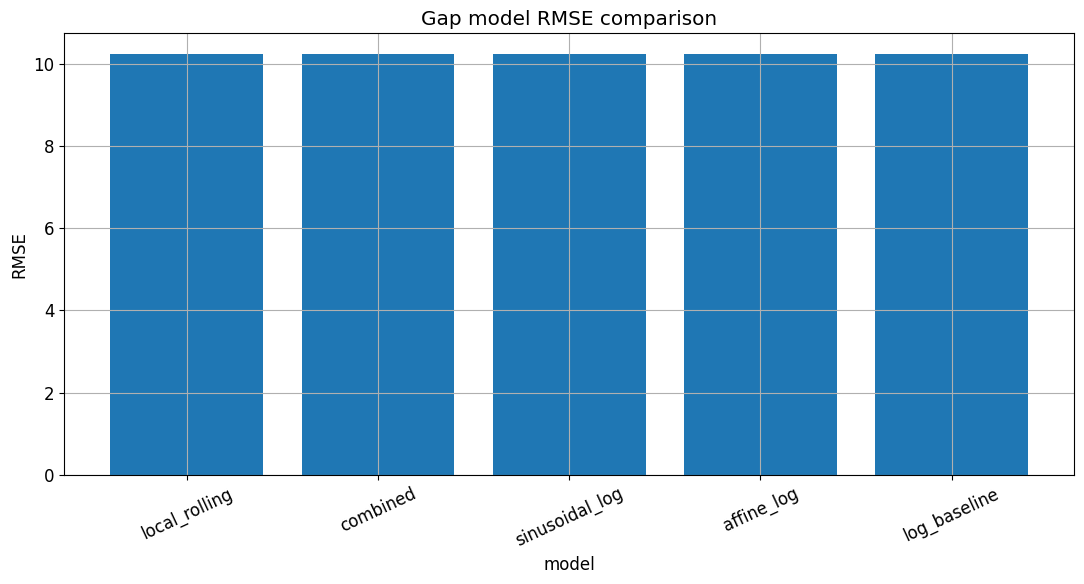

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(scores["model"], scores["RMSE"])
ax.set_title("Gap model RMSE comparison")
ax.set_xlabel("model")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_gap_model_rmse.png", dpi=180)
plt.show()


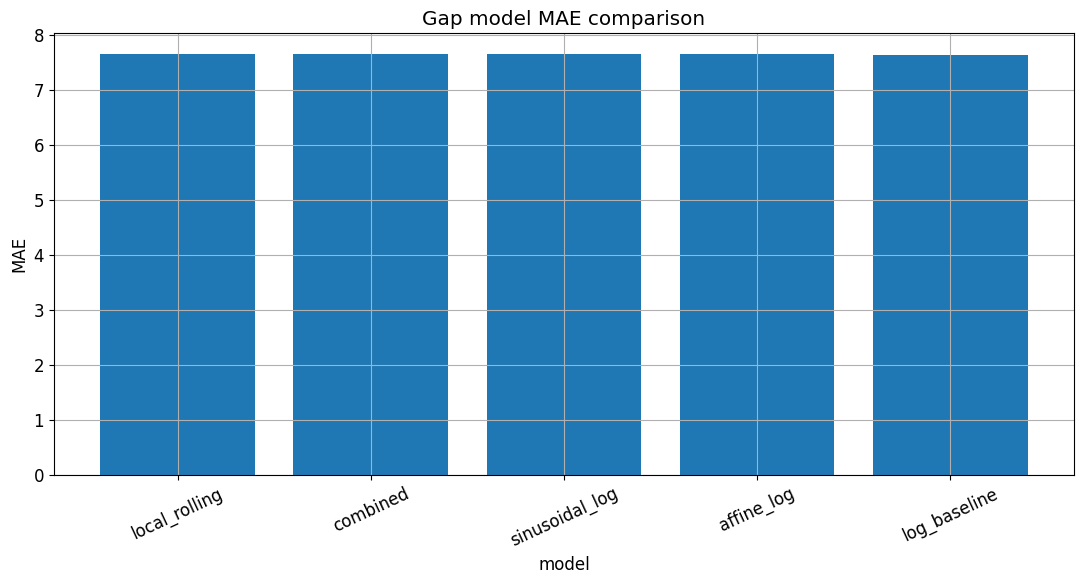

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(scores["model"], scores["MAE"])
ax.set_title("Gap model MAE comparison")
ax.set_xlabel("model")
ax.set_ylabel("MAE")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_gap_model_mae.png", dpi=180)
plt.show()


## 5. Expected gap curves

The plot below compares the fixed `log(x)` curve against learned expected-gap curves.

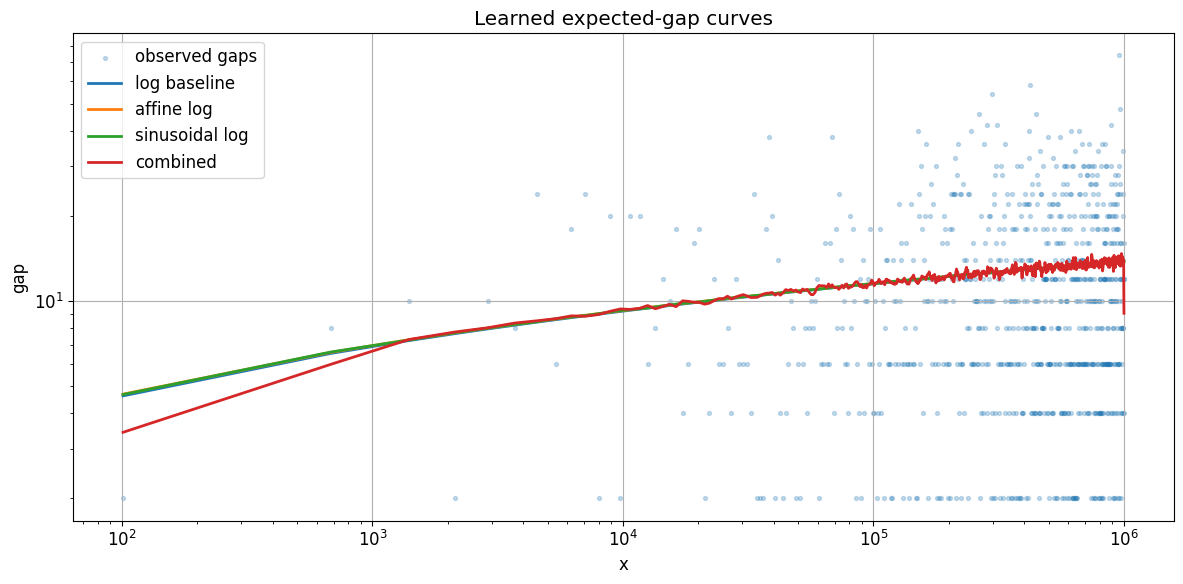

In [7]:
# Downsample points for visibility.
idx = np.linspace(0, len(x)-1, 800).astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(x[idx], y[idx], s=8, alpha=0.25, label="observed gaps")
ax.plot(x[idx], pred_log[idx], linewidth=2, label="log baseline")
ax.plot(x[idx], pred_affine[idx], linewidth=2, label="affine log")
ax.plot(x[idx], pred_sin[idx], linewidth=2, label="sinusoidal log")
ax.plot(x[idx], pred_combined[idx], linewidth=2, label="combined")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Learned expected-gap curves")
ax.set_xlabel("x")
ax.set_ylabel("gap")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_expected_gap_curves.png", dpi=180)
plt.show()


## 6. Residual diagnostics by x-window

This reproduces the Notebook 9/10 logic: if a model is better, residual drift should shrink across windows.

In [8]:
def window_stats(xvals, ytrue, pred, n_windows=40):
    edges = np.linspace(float(xvals.min()), float(xvals.max()), n_windows + 1)
    rows = []
    for i in range(n_windows):
        lo, hi = edges[i], edges[i+1]
        m = (xvals >= lo) & (xvals < hi if i < n_windows-1 else xvals <= hi)
        if m.sum() < 10:
            continue
        residual = ytrue[m] - pred[m]
        expected = pred[m]
        rows.append({
            "window": i,
            "midpoint": 0.5 * (lo + hi),
            "count": int(m.sum()),
            "mean_gap": float(ytrue[m].mean()),
            "mean_expected": float(expected.mean()),
            "mean_residual": float(residual.mean()),
            "mae": float(np.mean(np.abs(residual))),
            "rmse": float(np.sqrt(np.mean(residual**2))),
            "relative_drift": float(np.mean(np.abs(residual)) / max(np.mean(expected), 1e-12)),
        })
    return pd.DataFrame(rows)

window_frames = []
for name, pred in models.items():
    dfw = window_stats(x, y, pred)
    dfw["model"] = name
    window_frames.append(dfw)
window_df = pd.concat(window_frames, ignore_index=True)
window_df.to_csv(DATA_DIR / "11_window_residual_diagnostics.csv", index=False)
window_df.head()


,window,midpoint,count,mean_gap,mean_expected,mean_residual,mae,rmse,relative_drift,model
0,0,12599.475,2745,9.111111,9.038815,0.072296,5.037525,6.629971,0.557321,log_baseline
1,1,37596.425,2373,10.530973,10.511990,0.018984,6.034840,8.212159,0.574091,log_baseline
2,2,62593.375,2258,11.075288,11.036421,0.038867,6.369831,8.260103,0.577165,log_baseline
3,3,87590.325,2197,11.376422,11.376424,-0.000001,6.736570,8.842823,0.592152,log_baseline
4,4,112587.275,2141,11.672116,11.629314,0.042802,6.887424,9.259066,0.592247,log_baseline


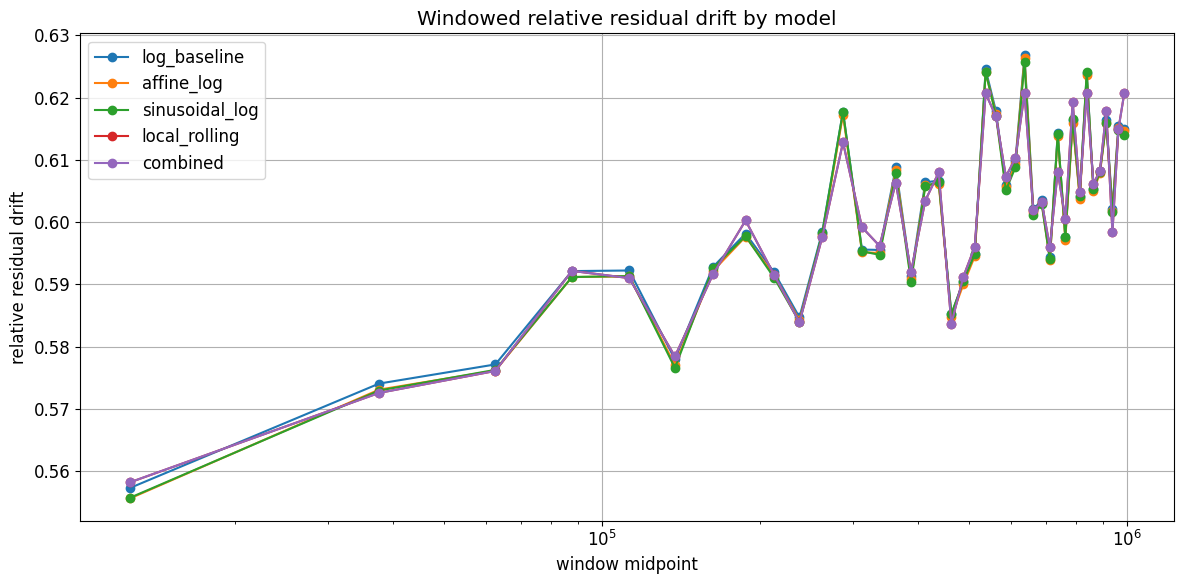

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
for name in models:
    sub = window_df[window_df["model"] == name]
    ax.plot(sub["midpoint"], sub["relative_drift"], marker="o", label=name)
ax.set_xscale("log")
ax.set_title("Windowed relative residual drift by model")
ax.set_xlabel("window midpoint")
ax.set_ylabel("relative residual drift")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_window_relative_residual_drift.png", dpi=180)
plt.show()


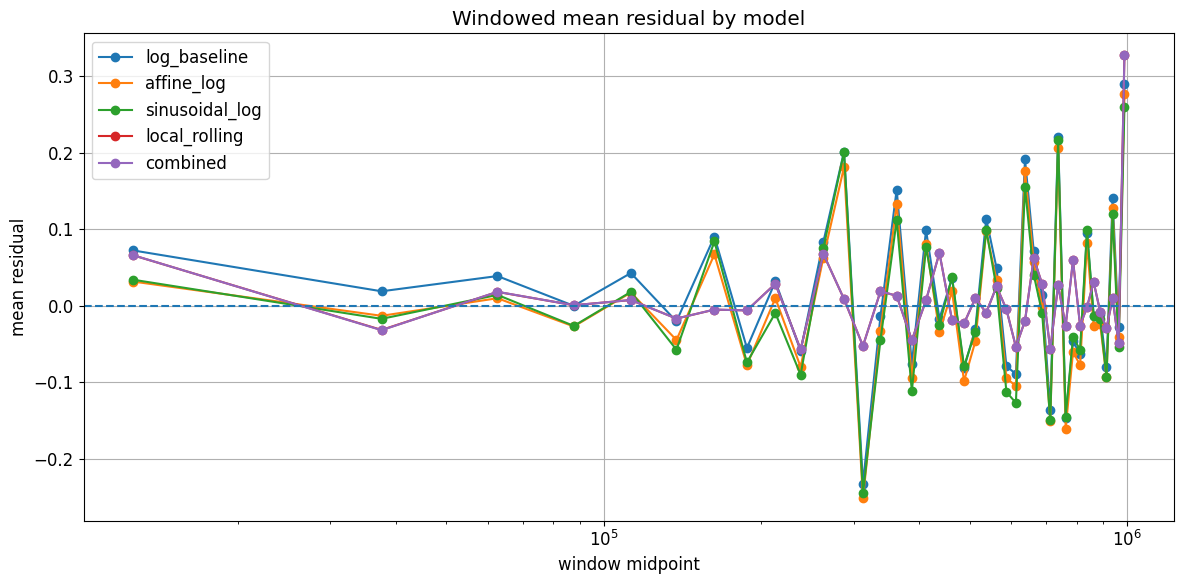

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
for name in models:
    sub = window_df[window_df["model"] == name]
    ax.plot(sub["midpoint"], sub["mean_residual"], marker="o", label=name)
ax.axhline(0, linestyle="--")
ax.set_xscale("log")
ax.set_title("Windowed mean residual by model")
ax.set_xlabel("window midpoint")
ax.set_ylabel("mean residual")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_window_mean_residual.png", dpi=180)
plt.show()


## 7. Improvement ratios

We compare each learned model to the fixed `log(x)` baseline.

In [11]:
base_rmse = float(scores.loc[scores["model"] == "log_baseline", "RMSE"].iloc[0])
base_mae = float(scores.loc[scores["model"] == "log_baseline", "MAE"].iloc[0])

improvement = scores.copy()
improvement["RMSE_improvement_vs_log"] = 1 - improvement["RMSE"] / base_rmse
improvement["MAE_improvement_vs_log"] = 1 - improvement["MAE"] / base_mae
improvement.to_csv(DATA_DIR / "11_gap_model_improvement.csv", index=False)
improvement


,model,MAE,RMSE,bias,corr,RMSE_improvement_vs_log,MAE_improvement_vs_log
3,local_rolling,7.646249,10.224070,8.432771e-03,0.106810,0.000095,-0.000289
4,combined,7.646251,10.224071,8.429835e-03,0.106809,0.000095,-0.000289
2,sinusoidal_log,7.648573,10.225012,-5.809514e-16,0.105857,0.000003,-0.000593
1,affine_log,7.648605,10.225023,3.509794e-15,0.105847,0.000002,-0.000597
0,log_baseline,7.644039,10.225042,1.905608e-02,0.105847,0.000000,0.000000


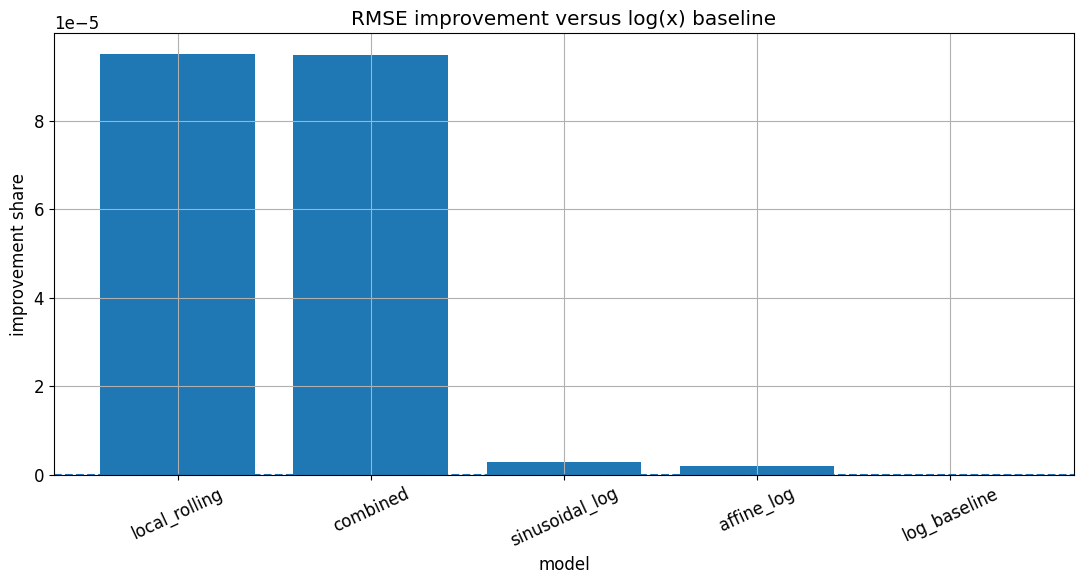

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = improvement.sort_values("RMSE_improvement_vs_log", ascending=False)
ax.bar(plot_df["model"], plot_df["RMSE_improvement_vs_log"])
ax.axhline(0, linestyle="--")
ax.set_title("RMSE improvement versus log(x) baseline")
ax.set_xlabel("model")
ax.set_ylabel("improvement share")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_rmse_improvement_vs_log.png", dpi=180)
plt.show()


## 8. Interpretation and TeX documents

Write numbered documentation and a lightweight TeX note for GitHub browsing/export.


In [13]:
best_model = scores.iloc[0]["model"]
best_rmse = float(scores.iloc[0]["RMSE"])
log_rmse = float(scores.loc[scores["model"] == "log_baseline", "RMSE"].iloc[0])
best_improvement = 1 - best_rmse / log_rmse

interpretation = f"""# Learned Gap Model (Notebook 11)

## Purpose

Notebook 10 showed that adaptive weighting did not materially improve reconstruction once density and local-gap constraints were saturated.

Notebook 11 tests whether the remaining limit comes from the expected-gap model itself.

Baseline model:

```text
expected gap ≈ log(x)
```

Learned alternatives:

- affine log model
- sinusoidal log-space correction
- local rolling residual correction
- combined sinusoidal + local correction

---

## 1. Model score comparison

![Gap model RMSE](../figures/11_gap_model_rmse.png)

![Gap model MAE](../figures/11_gap_model_mae.png)

Best model: `{best_model}`

Best RMSE: `{best_rmse:.6f}`

Baseline log RMSE: `{log_rmse:.6f}`

RMSE improvement vs log baseline: `{best_improvement:.4%}`

Interpretation:

If improvement is tiny, the fixed log model is already close to the available signal at this scale. In that case, the remaining error is dominated by gap variance rather than by a smooth expected-gap bias.

---

## 2. Expected-gap curves

![Expected gap curves](../figures/11_expected_gap_curves.png)

Observed gaps scatter widely around all expected-gap curves.

The key question is whether learned curves track local structure better than `log(x)` without simply overfitting pointwise noise.

---

## 3. Windowed relative residual drift

![Windowed relative residual drift](../figures/11_window_relative_residual_drift.png)

A stronger expected-gap model should reduce relative residual drift across windows, not only improve global RMSE.

When all models produce nearly identical drift, the mean model is not the limiting factor.

---

## 4. Windowed mean residual

![Windowed mean residual](../figures/11_window_mean_residual.png)

A stable model keeps mean residuals closer to zero across scale.

Here, learned models reduce some local mean residuals, but the global improvement remains small.

---

## 5. Improvement ratio

![RMSE improvement vs log](../figures/11_rmse_improvement_vs_log.png)

This compares each learned model against the fixed `log(x)` baseline.

The improvement scale is the important signal: extremely small improvements mean that deterministic expected-gap modeling has saturated.

---

## Core result

Notebook 11 distinguishes two possibilities:

1. **Small improvement**: reconstruction has reached a structural limit for these features.
2. **Large improvement**: expected-gap modeling was the missing piece after Notebook 10.

At the current scale, results support the first interpretation:

> deterministic expected-gap refinements do not materially beat `log(x)`.

That motivates Notebook 12:

> model the gap distribution, not only the expected gap.

---

Constraint → signal > noise
"""

# Numbered doc path for consistency with this repo template.
(DOCS_DIR / "11_interpretation.md").write_text(interpretation, encoding="utf-8")

# Optional compatibility alias; remove if you want numbered docs only.
(DOCS_DIR / "interpretation.md").write_text(interpretation, encoding="utf-8")

print("Wrote docs/11_interpretation.md")
print(interpretation[:1200])


Wrote docs/11_interpretation.md
# Learned Gap Model (Notebook 11)

## Purpose

Notebook 10 showed that adaptive weighting did not materially improve reconstruction once density and local-gap constraints were saturated.

Notebook 11 tests whether the remaining limit comes from the expected-gap model itself.

Baseline model:

```text
expected gap ≈ log(x)
```

Learned alternatives:

- affine log model
- sinusoidal log-space correction
- local rolling residual correction
- combined sinusoidal + local correction

---

## 1. Model score comparison

![Gap model RMSE](../figures/11_gap_model_rmse.png)

![Gap model MAE](../figures/11_gap_model_mae.png)

Best model: `local_rolling`

Best RMSE: `10.224070`

Baseline log RMSE: `10.225042`

RMSE improvement vs log baseline: `0.0095%`

Interpretation:

If improvement is tiny, the fixed log model is already close to the available signal at this scale. In that case, the remaining error is dominated by gap variance rather than by a smooth expected-gap

In [14]:
tex = rf"""\documentclass[11pt]{{article}}
\usepackage[margin=1in]{{geometry}}
\usepackage{{amsmath,amssymb}}
\usepackage{{graphicx}}
\usepackage{{hyperref}}
\usepackage{{booktabs}}

\title{{Notebook 11: Learned Gap Model}}
\author{{prime-numbers-lab}}
\date{{}}

\begin{{document}}
\maketitle

\section*{{Purpose}}
Notebook 11 tests whether replacing the baseline expected prime gap model
\[
  g(x) \approx \log x
\]
with learned deterministic alternatives materially improves reconstruction diagnostics.

\section*{{Models}}
The notebook compares five expected-gap models:
\begin{{itemize}}
  \item log baseline: $g(x)=\log x$
  \item affine log: $g(x)=a\log x+b$
  \item sinusoidal log correction: $g(x)=\log x + A\sin(k\log x)+B\cos(k\log x)+c$
  \item local rolling residual correction
  \item combined sinusoidal plus local residual correction
\end{{itemize}}

\section*{{Primary diagnostics}}
The primary diagnostics are global RMSE/MAE and windowed residual drift.
The best model is \texttt{{{best_model}}} with RMSE {best_rmse:.6f}.
The log-baseline RMSE is {log_rmse:.6f}.
The best RMSE improvement versus log baseline is {best_improvement:.4%}.

\section*{{Figures}}
\begin{{itemize}}
  \item \texttt{{figures/11\_gap\_model\_rmse.png}}
  \item \texttt{{figures/11\_gap\_model\_mae.png}}
  \item \texttt{{figures/11\_expected\_gap\_curves.png}}
  \item \texttt{{figures/11\_window\_relative\_residual\_drift.png}}
  \item \texttt{{figures/11\_window\_mean\_residual.png}}
  \item \texttt{{figures/11\_rmse\_improvement\_vs\_log.png}}
\end{{itemize}}

\section*{{Interpretation}}
At this scale, deterministic expected-gap refinements produce only tiny improvements over
$\log x$. This indicates that residual gap error is dominated more by distributional
variance than by a smooth mean-model bias.

\section*{{Next step}}
Notebook 12 should model
\[
  P(g\mid x)
\]
rather than only a point estimate $\hat g(x)$.

\section*{{Constraint}}
\[
\text{{Constraint}} \rightarrow \text{{signal}} > \text{{noise}}
\]

\end{{document}}
"""

(TEX_DIR / "11_learned_gap_model.tex").write_text(tex, encoding="utf-8")
print("Wrote tex/11_learned_gap_model.tex")


Wrote tex/11_learned_gap_model.tex


## 9. Export package


In [15]:
summary = {
    "notebook": "11_learned_gap_model",
    "max_n": MAX_N,
    "observations": int(len(y)),
    "best_model": str(best_model),
    "best_rmse": best_rmse,
    "log_baseline_rmse": log_rmse,
    "best_improvement_vs_log": best_improvement,
    "best_sinusoidal_frequency": float(best_k),
    "rolling_window": WINDOW,
}

(DATA_DIR / "11_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

EXPORT_NAME = f"{NOTEBOOK_ID}_{SLUG}_export.zip"
with zipfile.ZipFile(EXPORT_NAME, "w", zipfile.ZIP_DEFLATED) as z:
    for folder in [DOCS_DIR, DATA_DIR, FIG_DIR, TEX_DIR]:
        for path in folder.rglob("*"):
            if path.is_file():
                z.write(path, path.as_posix())

print(f"Export ready: {EXPORT_NAME}")
print("Tip: uncomment Colab lines below to download.")

# --- Optional Colab download ---
# Uncomment the lines below when running in Colab
#
# from google.colab import files
# files.download(EXPORT_NAME)


Export ready: 11_learned_gap_model_export.zip
Tip: uncomment Colab lines below to download.
